# Feature Importance Analysis

In this notebook we perform feature analysis on our 3 best models from the previous experiment.

For dataset 1 it can be concluded that the best model for dataset 1 is either our imbalanced or our Logistic Regression model with weighted balancing, for this feature analysis we will use the weighted Logistic Regression model

For dataset 2 it can be concluded that the best model for dataset 2 is either our imbalanced or our Logistic Regression model with weighted balancing, for this feature analysis we will use the weighted Logistic Regression model

For dataset 3 our weighted Logistic Regression model seemed to perform the best on average across our statistics so we will use this model for feature analysis

In [19]:
#All imports needed for this experiment

import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np


## Helper Functions

In [20]:
feature_name_map = {
    'bp':   'Blood pressure (mm/Hg)',
    'sg':   'Specific gravity of urine',
    'al':   'Albumin in urine',
    'su':   'Sugar in urine',
    'bu':   'Blood urea (mg/dl)',
    'sc':   'Serum creatinine (mg/dl)',
    'sod':  'Sodium level (mEq/L)',
    'pot':  'Potassium level (mEq/L)',
    'hemo': 'Hemoglobin level (gms)',
    'rbc':  'Red blood cell count (millions/cumm)',
    'wc':   'White blood cell count (cells/cumm)',
    'rc':   'Red blood cell count (millions/cumm)',
    'htn':  'Hypertension (yes/no)'
}

In [22]:
def plot_encoded_feature_importance(model, feature_names, title, top_n=15):

    #Get feature importances from model
    importances = np.abs(model.coef_[0])
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=feature_importance_df,
        x='importance',
        y='feature',
        hue='feature',
        palette='RdYlGn_r',
        legend=False,
        ax=ax
    )
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Coefficient Magnitude')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Top {top_n} Most Important Features:')
    print('=' * 45)

    rank = 1
    for index, row in feature_importance_df.iterrows():
        print(f'{rank:>2}. {row['feature']:<10s} {row['importance']:.4f}')
        rank +=1

In [ ]:
def plot_original_feature_importance(model, numeric_features, title):
    original_importances = {}
    importances = np.abs(model.coef_[0])

    for feat in numeric_features:
        idx = numeric_features.index(feat)
        original_importances[feature_name_map[feat]] = importances[idx]

    orginal_importance_series = pd.Series(original_importances).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    orginal_importance_series.plot(kind='barh', ax=ax, color='#4A90D9')
    ax.set_title(title,
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Importance')
    plt.tight_layout()
    plt.show()


## Features For Each Dataset

In [ ]:
numeric_features  = joblib.load('..\\models\\numeric_features.joblib')

print("Feature Names Across Datasets: \n")
print("Numeric features:", numeric_features)

Feature Names Across Datasets: 

Numeric features: ['bp', 'sg', 'al', 'su', 'bu', 'sc', 'sod', 'pot', 'hemo']
Categorical features: ['rbc', 'wc', 'rc', 'htn']


## Dataset 1 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor And Models

In [25]:
# Load preprocessor and model for dataset 1
preprocessor = joblib.load('..\\models\\dataset_1\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_1\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

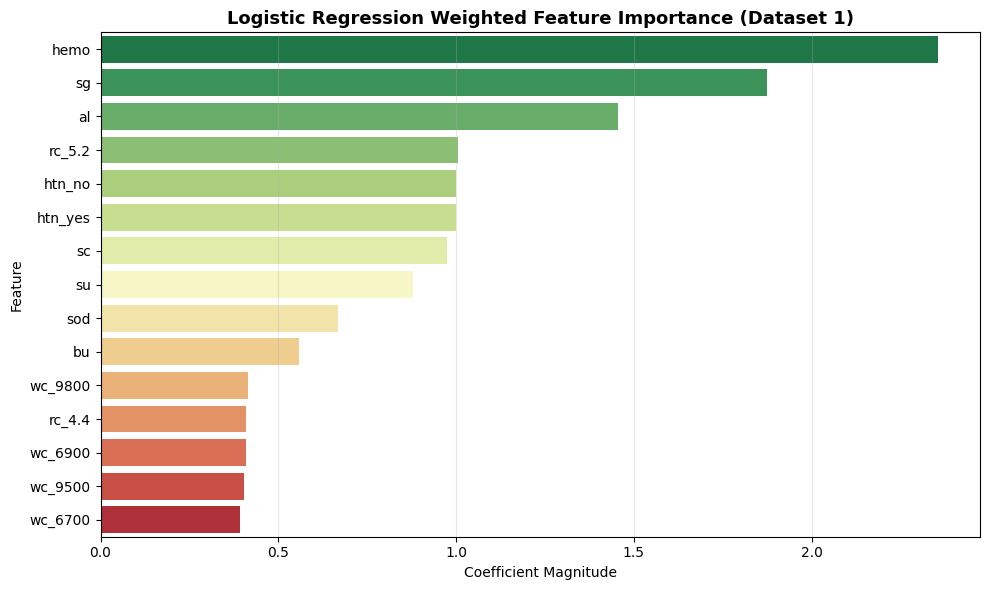

Top 15 Most Important Features:
 1. hemo       2.3555
 2. sg         1.8743
 3. al         1.4546
 4. rc_5.2     1.0041
 5. htn_no     0.9992
 6. htn_yes    0.9984
 7. sc         0.9734
 8. su         0.8779
 9. sod        0.6670
10. bu         0.5584
11. wc_9800    0.4158
12. rc_4.4     0.4087
13. wc_6900    0.4081
14. wc_9500    0.4023
15. wc_6700    0.3918


In [ ]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 1)')

### Plot Original Feature Importance

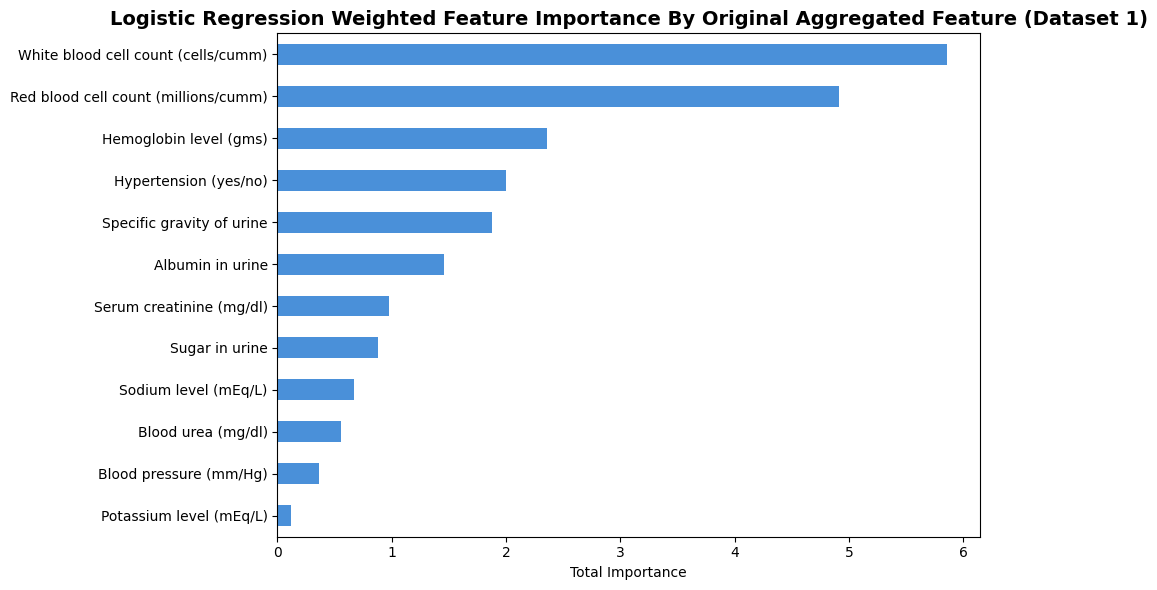

In [ ]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 1)')

## Dataset 2 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor and Models

In [29]:
# Load preprocessor and model for dataset 2
preprocessor = joblib.load('..\\models\\dataset_2\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_2\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

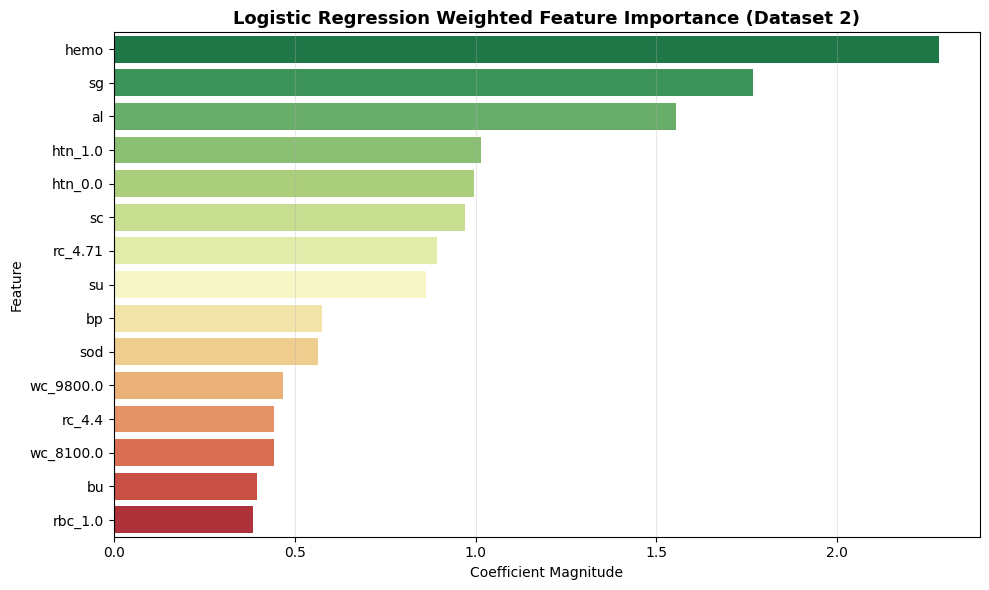

Top 15 Most Important Features:
 1. hemo       2.2802
 2. sg         1.7663
 3. al         1.5534
 4. htn_1.0    1.0144
 5. htn_0.0    0.9970
 6. sc         0.9702
 7. rc_4.71    0.8938
 8. su         0.8619
 9. bp         0.5748
10. sod        0.5635
11. wc_9800.0  0.4673
12. rc_4.4     0.4443
13. wc_8100.0  0.4430
14. bu         0.3972
15. rbc_1.0    0.3851


In [ ]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 2)')

### Plot Original Feature Importance

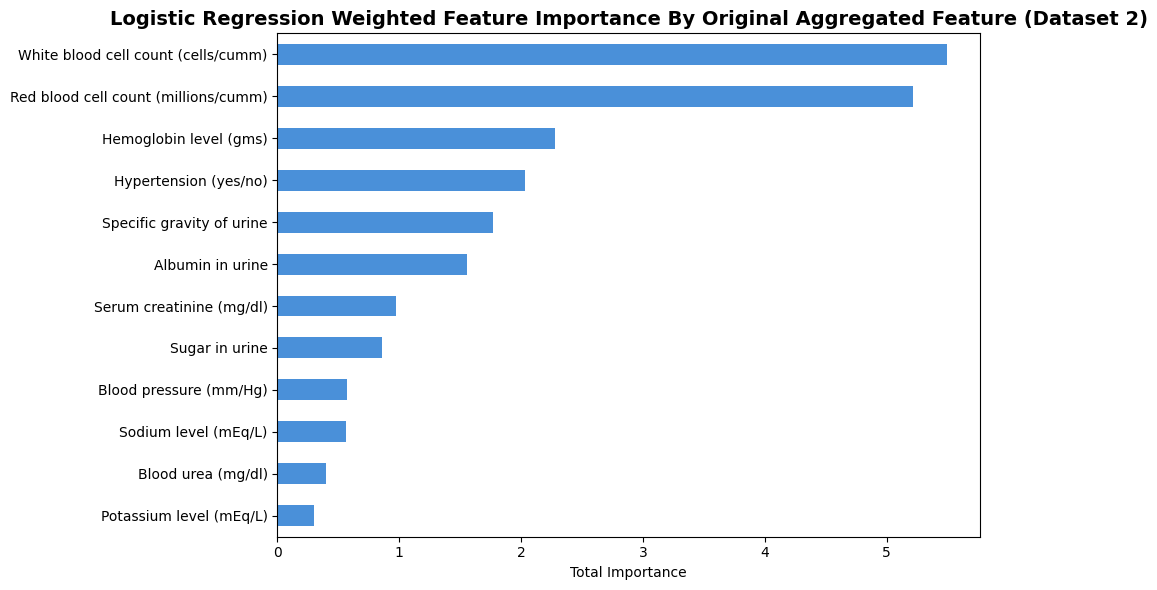

In [ ]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 2)')

## Dataset 3 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor And Models

In [33]:
preprocessor = joblib.load('..\\models\\dataset_3\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_3\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

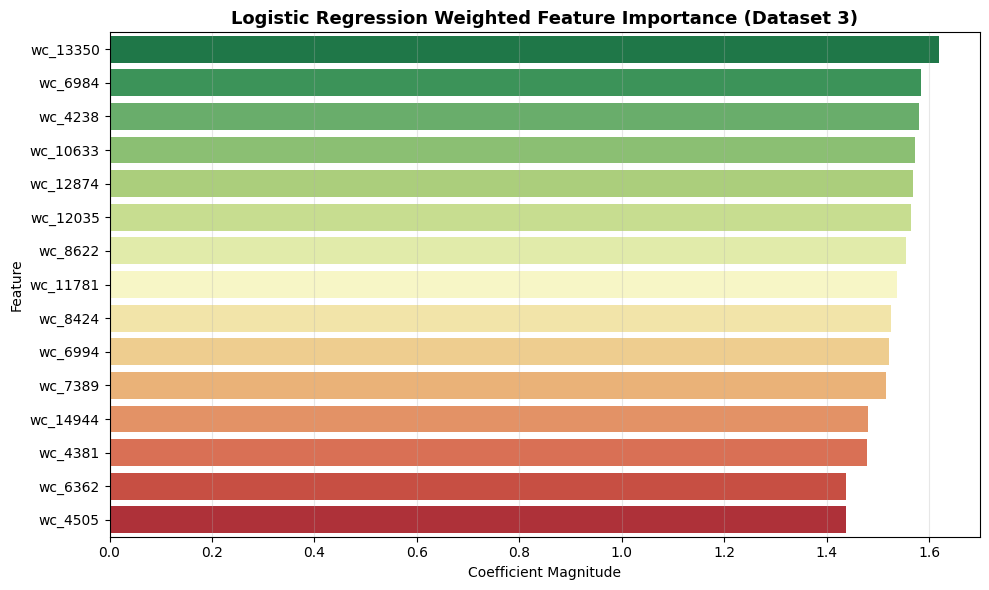

Top 15 Most Important Features:
 1. wc_13350   1.6182
 2. wc_6984    1.5845
 3. wc_4238    1.5809
 4. wc_10633   1.5729
 5. wc_12874   1.5679
 6. wc_12035   1.5647
 7. wc_8622    1.5550
 8. wc_11781   1.5380
 9. wc_8424    1.5253
10. wc_6994    1.5221
11. wc_7389    1.5158
12. wc_14944   1.4808
13. wc_4381    1.4783
14. wc_6362    1.4384
15. wc_4505    1.4379


In [ ]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 3)')

### Plot Original Feature Importance

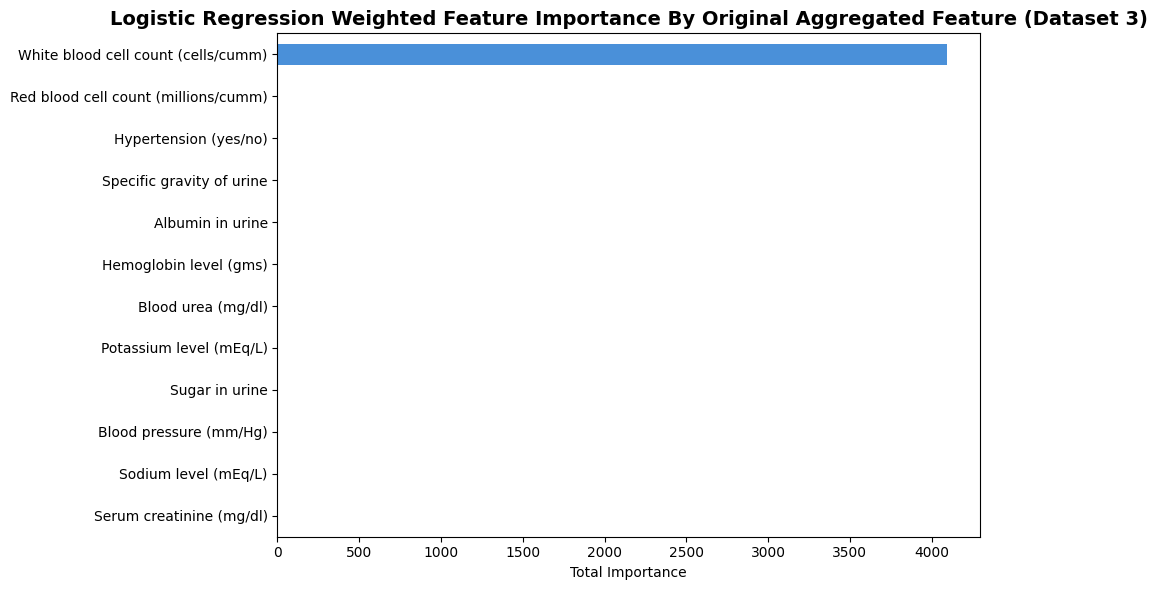

In [ ]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 3)')